In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler



from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_curve)


In [3]:
df_train = pd.read_csv ("customer_churn_dataset-training-master.csv")
df_test = pd.read_csv ("customer_churn_dataset-testing-master.csv")

In [4]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [5]:
df_train.info()
df_train.shape



<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


(440833, 12)

In [6]:
df_train.isnull().sum()


CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [8]:
df_train.duplicated().sum()

np.int64(0)

In [9]:
df_train = df_train.drop(columns=["CustomerID"])
df_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [10]:
df_train = df_train.dropna()
df_train = df_train.drop_duplicates()
print("Shape after dropping duplicates:", df_train.shape)

Shape after dropping duplicates: (440832, 11)


In [12]:
numerical_columns = ["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Last Interaction"]

In [13]:
categorical_columns = ["Gender", "Subscription Type", "Contract Length"]

In [15]:
df_train.describe().round(2)


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00
mean,39.37,31.26,15.81,3.60,12.97,631.62,14.48,0.57
std,12.44,17.26,8.59,3.07,8.26,240.80,8.60,0.50
min,18.00,1.00,1.00,0.00,0.00,100.00,1.00,0.00
25%,29.00,16.00,9.00,1.00,6.00,480.00,7.00,0.00
50%,39.00,32.00,16.00,3.00,12.00,661.00,14.00,1.00
75%,48.00,46.00,23.00,6.00,19.00,830.00,22.00,1.00
max,65.00,60.00,30.00,10.00,30.00,1000.00,30.00,1.00


In [16]:
df_train['Churn'].value_counts(normalize=True) # 56% churned , 43% retained

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

In [17]:
df_train["Churn"] = df_train["Churn"].astype(int)
for col in numerical_columns:
    df_train[col] = df_train[col].astype(float)

df_train.dtypes

Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
Churn                  int64
dtype: object

In [18]:
for column in categorical_columns:
    print("\n", column)
    print(df_train[column].value_counts())


 Gender
Gender
Male      250252
Female    190580
Name: count, dtype: int64

 Subscription Type
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

 Contract Length
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


C:\Users\Nadia\AppData\Local\Temp\ipykernel_30776\2306548093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x="Churn", palette="Set2")


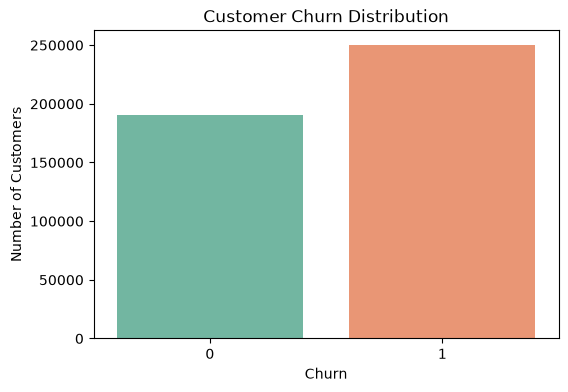

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x="Churn", palette="Set2")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

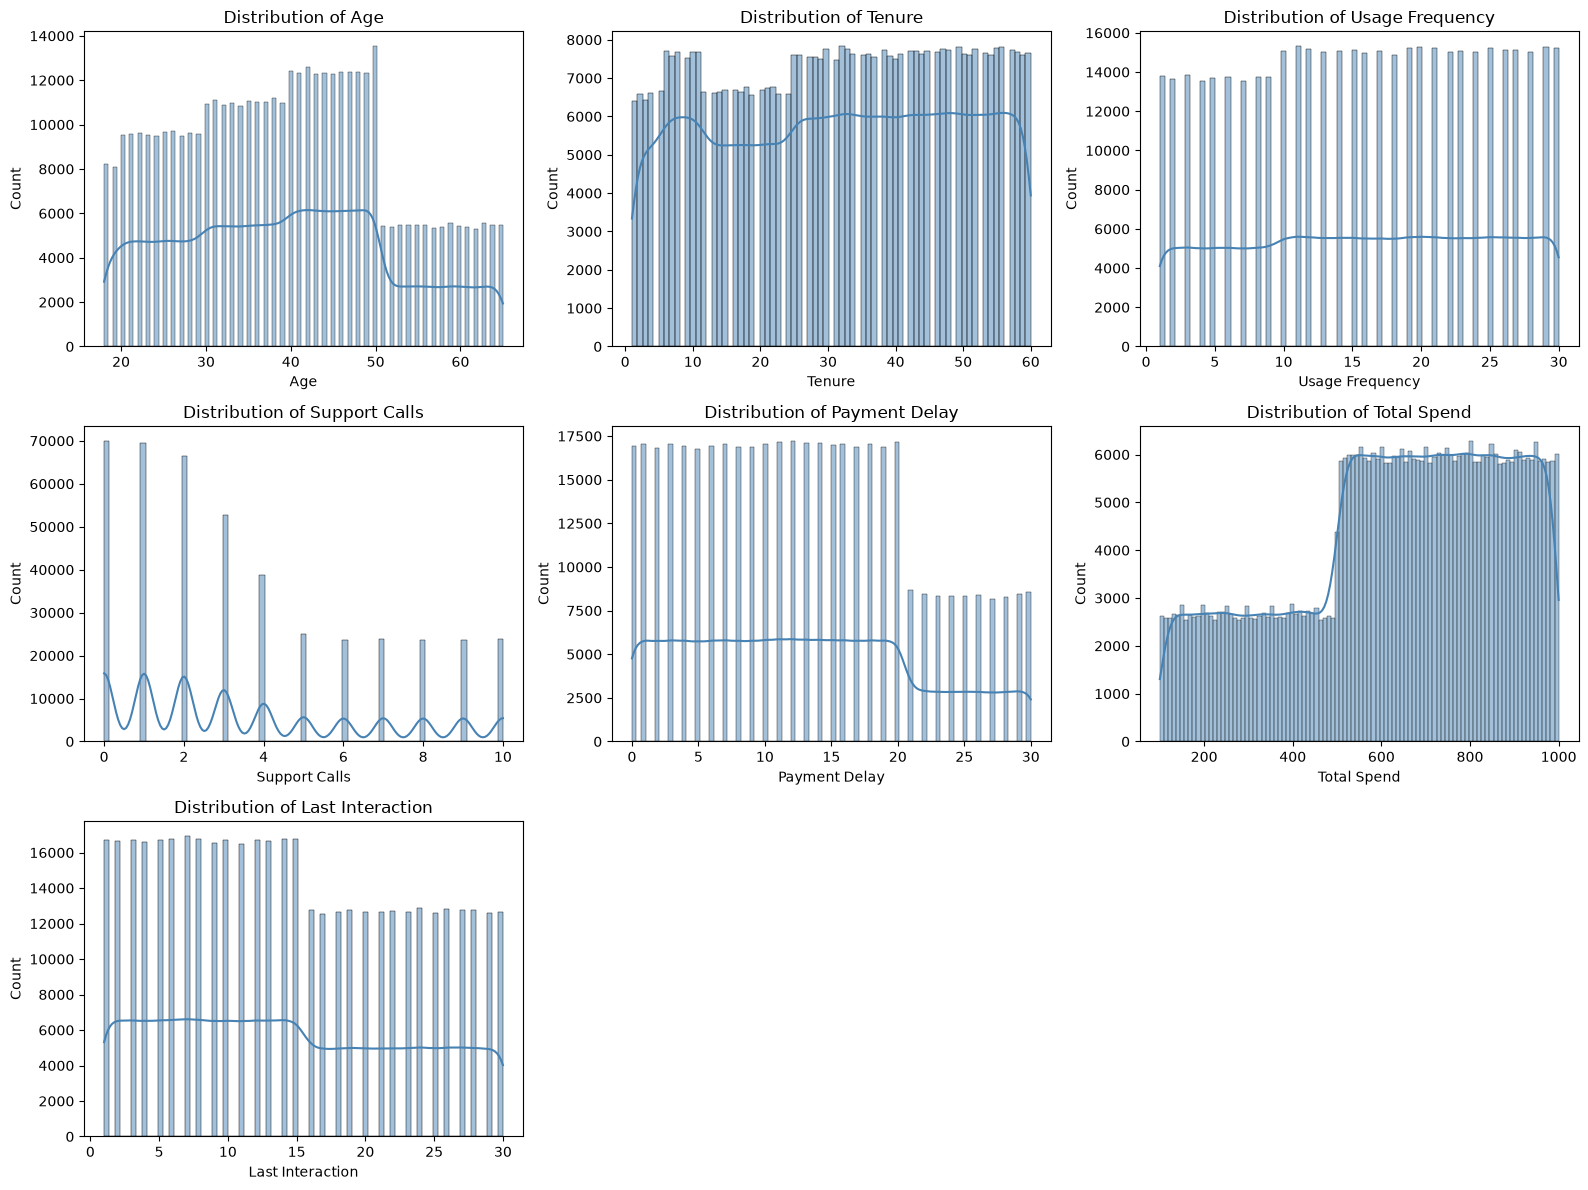

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

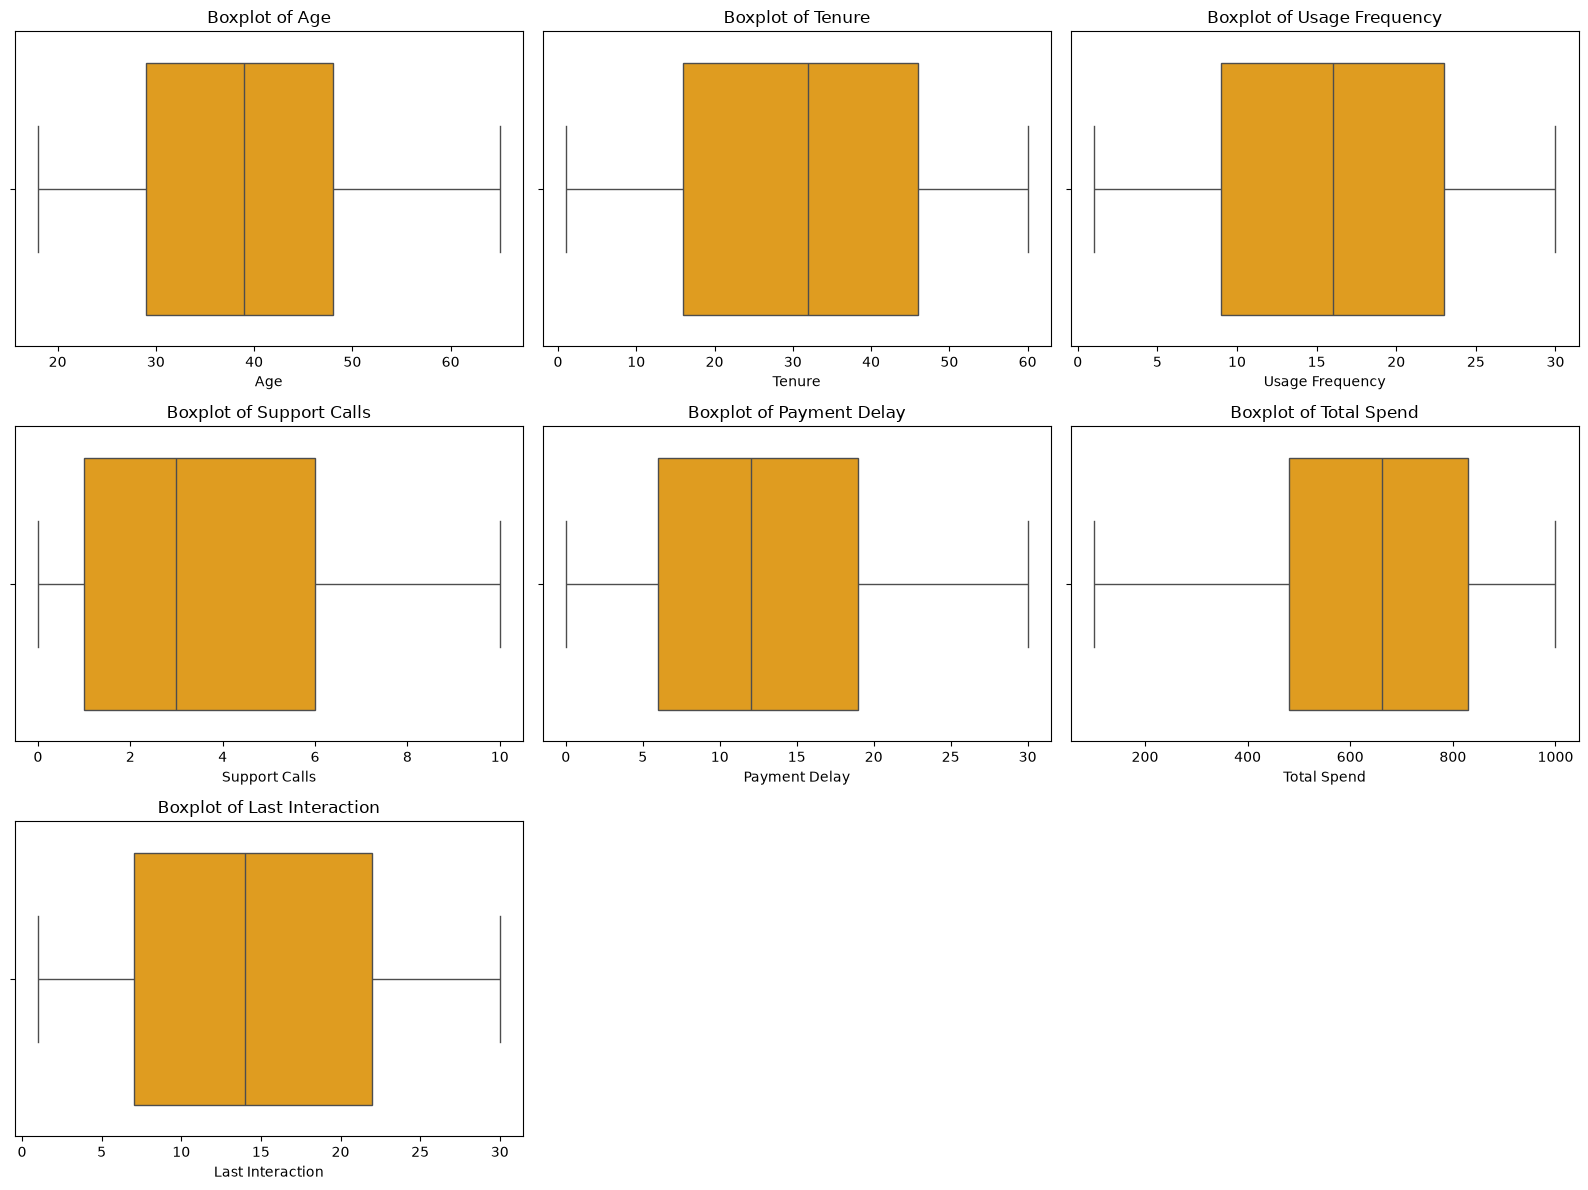

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df_train[col], ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot of {col}")
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

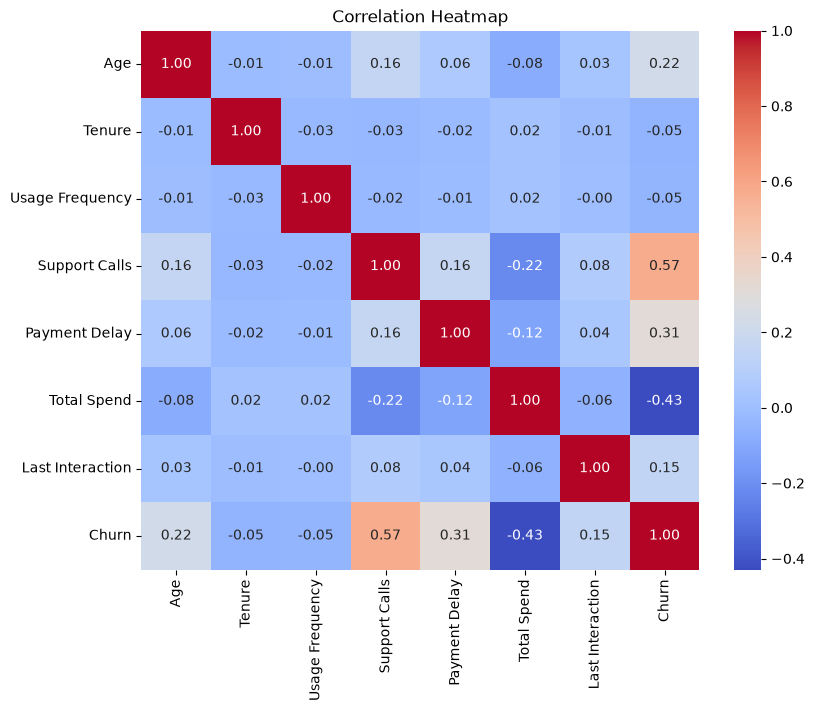

In [19]:
plt.figure(figsize=(9, 7))
corr = df_train[numerical_columns + ["Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

C:\Users\Nadia\AppData\Local\Temp\ipykernel_30776\1596456033.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i], palette="viridis")
C:\Users\Nadia\AppData\Local\Temp\ipykernel_30776\1596456033.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i], palette="viridis")
C:\Users\Nadia\AppData\Local\Temp\ipykernel_30776\1596456033.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i],

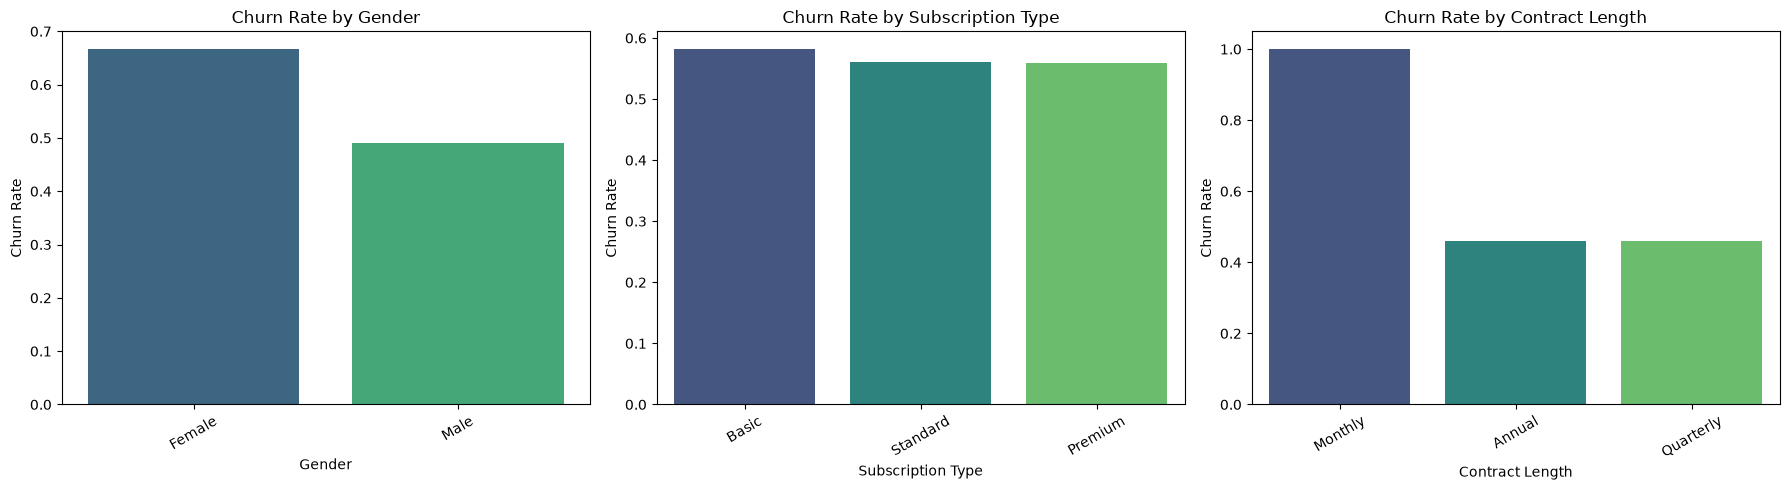

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_columns):
    churn_by_cat = df_train.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=churn_by_cat.index, y=churn_by_cat.values, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [19]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [20]:
df_test.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [21]:
df_test.duplicated().sum()

np.int64(0)

In [22]:
df_test = df_test.dropna()
df_test = df_test.drop_duplicates()
df_test = df_test.drop(columns=["CustomerID"])

df_test["Churn"] = df_test["Churn"].astype(int)
for col in numerical_columns:
    df_test[col] = df_test[col].astype(float)

print("Test shape after cleaning:", df_test.shape)
df_test.head()

Test shape after cleaning: (64374, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1
1,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0
2,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0
3,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0
4,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0


In [23]:
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=["Churn"])
y = df_train["Churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test = df_test.drop(columns=["Churn"])
y_test = df_test["Churn"]

print("X_train:", X_train.shape)
print (" X_val:", X_val.shape )
print( "X_test:", X_test.shape)

X_train: (352665, 10)
 X_val: (88167, 10)
X_test: (64374, 10)


In [24]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoder.fit(df_train[categorical_columns])

train_encoded = pd.DataFrame(
    encoder.transform(df_train[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=df_train.index,
)
test_encoded = pd.DataFrame(
    encoder.transform(df_test[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=df_test.index,
)

df_train = pd.concat([df_train.drop(columns=categorical_columns), train_encoded], axis=1)
df_test = pd.concat([df_test.drop(columns=categorical_columns), test_encoded], axis=1)

df_train.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1,0.0,0.0,1.0,0.0,0.0
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1,0.0,0.0,0.0,1.0,0.0
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1,0.0,0.0,0.0,0.0,1.0
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1,1.0,0.0,1.0,1.0,0.0
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1,1.0,0.0,0.0,1.0,0.0


In [25]:
scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_val[numerical_columns] = scaler.transform(X_val[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

X_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
318331,0.210377,Male,0.855271,1.651238,-0.197156,-1.085320,Standard,Annual,1.300956,-0.753449
429062,-0.512784,Female,0.681455,0.137056,-0.848223,0.246158,Standard,Annual,1.478368,-0.288211
60074,-1.075242,Female,-1.056712,1.651238,0.128377,-0.116972,Premium,Quarterly,0.698312,-1.102379
12759,-0.834189,Female,-1.288467,0.835909,2.081578,1.335549,Basic,Quarterly,-2.130477,0.525957
357321,-0.111028,Male,-1.230528,0.486483,-1.173756,-1.569494,Basic,Annual,0.195568,0.409648
